In [34]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score
import seaborn as sns
from sklearn.metrics import log_loss
from scipy.special import logsumexp
from scipy.stats import bernoulli
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from statsmodels.graphics.mosaicplot import mosaic
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

## 1. Loading Dataset

In [2]:
mcdonalds=pd.read_csv("mcdonalds.csv")
mcdonalds.head()

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender
0,No,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,-3,61,Every three months,Female
1,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,+2,51,Every three months,Female
2,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,+1,62,Every three months,Female
3,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,+4,69,Once a week,Female
4,No,Yes,No,Yes,Yes,Yes,Yes,No,No,Yes,No,+2,49,Once a month,Male


In [3]:
mcdonalds.isnull().sum()

yummy             0
convenient        0
spicy             0
fattening         0
greasy            0
fast              0
cheap             0
tasty             0
expensive         0
healthy           0
disgusting        0
Like              0
Age               0
VisitFrequency    0
Gender            0
dtype: int64

## 2. Exploring Dataset

In [4]:
df=mcdonalds.iloc[:,0:11].replace("Yes",1).replace("No",0)
mean=df.mean().round(2)
mean

C:\Users\KIIT\AppData\Local\Temp\ipykernel_22732\3255503938.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=mcdonalds.iloc[:,0:11].replace("Yes",1).replace("No",0)


yummy         0.55
convenient    0.91
spicy         0.09
fattening     0.87
greasy        0.53
fast          0.90
cheap         0.60
tasty         0.64
expensive     0.36
healthy       0.20
disgusting    0.24
dtype: float64

#### 2.1) Perform PCA

In [5]:
pca=PCA()
pca.fit(df)

# Standard deviation of each component
pca_std=np.round(np.sqrt(pca.explained_variance_), 2)

# Proportion of Variance
pca_pv=np.round(pca.explained_variance_ratio_, 3)

# Cumulative Proportion
pca_cp=pca_pv.cumsum()

pca_df=pd.DataFrame({
    "Standard Deviation" : pca_std,
    "Proportion of Variance" : pca_pv,
    "Cumulative Proportion" : pca_cp
})
print(pca_df)

# Storing the component
component=pca.components_

# Create a DataFrame with components
print("\nPCA Components:")
component_df=pd.DataFrame(
    np.round(component, 3),
    columns=df.columns,
    index=[f"PC{i+1}" for i in range(len(component))]
).T
component_df

    Standard Deviation  Proportion of Variance  Cumulative Proportion
0                 0.76                   0.299                  0.299
1                 0.61                   0.193                  0.492
2                 0.50                   0.133                  0.625
3                 0.40                   0.083                  0.708
4                 0.34                   0.059                  0.767
5                 0.31                   0.050                  0.817
6                 0.29                   0.044                  0.861
7                 0.28                   0.040                  0.901
8                 0.27                   0.037                  0.938
9                 0.25                   0.032                  0.970
10                0.24                   0.029                  0.999

PCA Components:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
yummy,0.477,-0.364,0.304,0.055,0.308,-0.171,-0.281,-0.013,-0.572,0.110,-0.045
convenient,0.155,-0.016,0.063,-0.142,-0.278,0.348,-0.060,0.113,0.018,0.666,0.542
spicy,0.006,-0.019,0.037,0.198,-0.071,0.355,0.708,-0.376,-0.400,0.076,-0.142
fattening,-0.116,0.034,0.322,-0.354,0.073,0.407,-0.386,-0.590,0.161,0.005,-0.251
greasy,-0.304,0.064,0.802,0.254,-0.361,-0.209,0.036,0.138,0.003,-0.009,-0.002
fast,0.108,0.087,0.065,-0.097,-0.108,0.595,-0.087,0.628,-0.166,-0.240,-0.339
cheap,0.337,0.611,0.149,0.119,0.129,0.103,-0.040,-0.140,-0.076,-0.428,0.489
tasty,0.472,-0.307,0.287,-0.003,0.211,0.077,0.360,0.073,0.639,-0.079,-0.020
expensive,-0.329,-0.601,-0.024,0.068,0.003,0.261,-0.068,-0.030,-0.067,-0.454,0.490
healthy,0.214,-0.077,-0.192,0.763,-0.288,0.178,-0.350,-0.176,0.186,0.038,-0.158


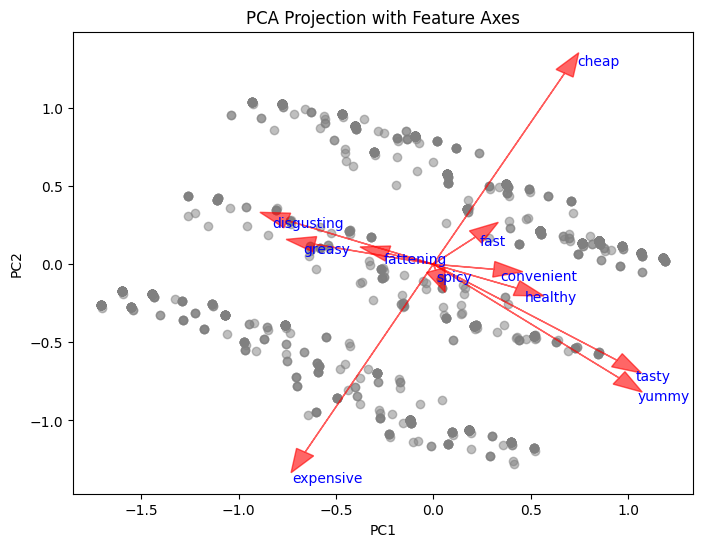

In [6]:
# PCA-transformed data
df_pca = pca.transform(df)

# Plot the PCA data (first 2 components)
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], color='grey', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection with Feature Axes')

# Plot projection axes
for i, feature in enumerate(df.columns):
    plt.arrow(0, 0,
              pca.components_[0, i]*2,
              pca.components_[1, i]*2,
              color='red', alpha=0.6, head_width=0.1)
    plt.text(pca.components_[0, i]*2.2,
             pca.components_[1, i]*2.2,
             feature, color='Blue', ha='left', va='top')
plt.show()

## 3. Extracting Segments

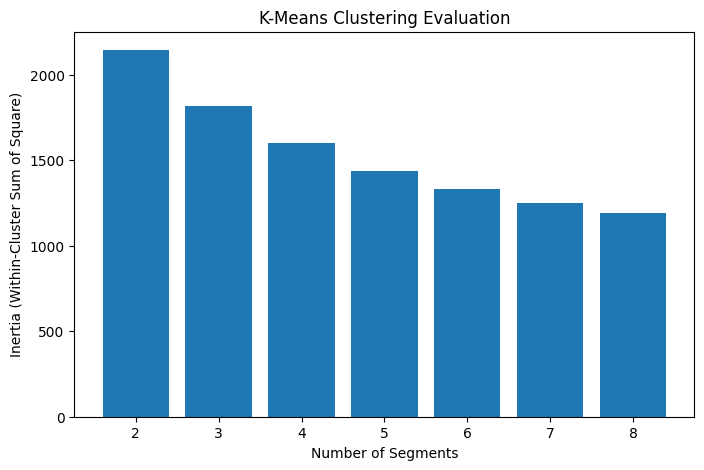

In [7]:
km_inertia=[]
kmeans={}

for k in range(2,9):      # k = 2 to 8
  km=KMeans(n_clusters=k, n_init=10, random_state=1234)
  km.fit(df)
  km_inertia.append(km.inertia_)
  kmeans[k] = km

# Plot inertia vs number of clusters
plt.figure(figsize=(8,5))
plt.bar(range(2,9), km_inertia)
plt.xlabel("Number of Segments")
plt.ylabel("Inertia (Within-Cluster Sum of Square)")
plt.title("K-Means Clustering Evaluation")
plt.show()

In [8]:
np.random.seed(1234)

nboot = 100
k_range = range(2, 9)
n_init = 10

cluster_stability = {k: [] for k in k_range}

for k in k_range:
    print(f"Bootstrapping for k = {k}")

    # Original model
    original_model = KMeans(n_clusters=k, n_init=n_init, random_state=1234)
    original_labels = original_model.fit_predict(df.values)

    for _ in range(nboot):
        # Bootstrap sampling
        indices = np.random.choice(len(df), size=len(df), replace=True)
        df_x_boot = df.iloc[indices]

        model = KMeans(n_clusters=k, n_init=n_init, random_state=1234)
        labels = model.fit_predict(df_x_boot.values)

        # Compare only overlapping rows
        original_indices = np.unique(indices)
        try:
            common_labels_orig = original_labels[original_indices]
            common_labels_boot = labels[[np.where(indices == idx)[0][0] for idx in original_indices]]
            ari = adjusted_rand_score(common_labels_orig, common_labels_boot)
            cluster_stability[k].append(ari)
        except IndexError:
            continue

# Print stability summary
print("\nAverage Stability (ARI) for each k:")
for k, aris in cluster_stability.items():
    print(f"k = {k}: ARI = {np.mean(aris):.3f}")

Bootstrapping for k = 2
Bootstrapping for k = 3
Bootstrapping for k = 4
Bootstrapping for k = 5
Bootstrapping for k = 6
Bootstrapping for k = 7
Bootstrapping for k = 8

Average Stability (ARI) for each k:
k = 2: ARI = 0.967
k = 3: ARI = 0.933
k = 4: ARI = 0.873
k = 5: ARI = 0.820
k = 6: ARI = 0.742
k = 7: ARI = 0.728
k = 8: ARI = 0.676


C:\Users\KIIT\AppData\Local\Temp\ipykernel_22732\2472691350.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cluster_stability[i] for i in k_vals],  labels=k_vals)


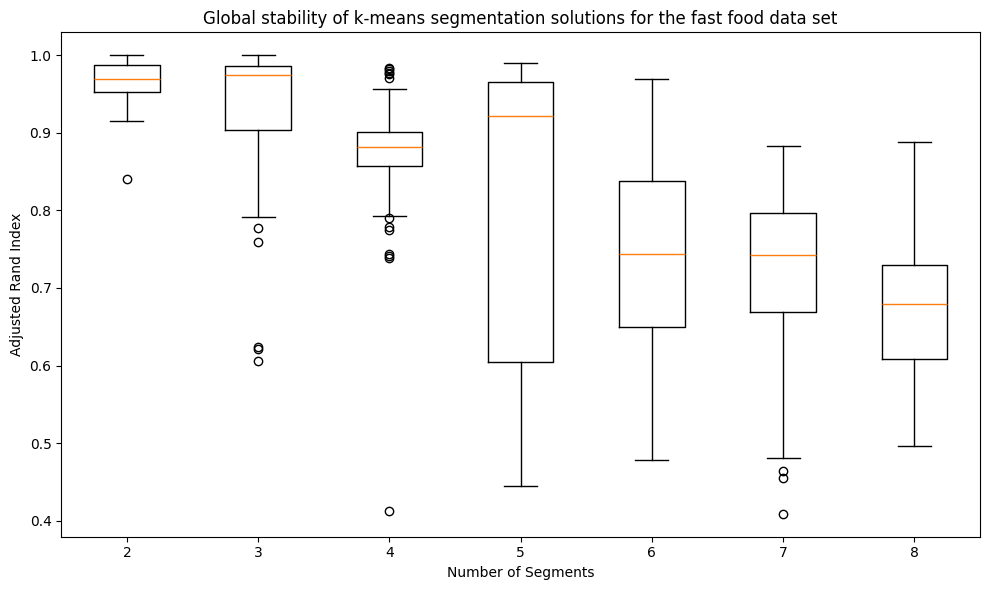

In [9]:
k_vals = list(cluster_stability.keys())
k_vals

plt.figure(figsize=(10, 6))
plt.boxplot([cluster_stability[i] for i in k_vals],  labels=k_vals)
plt.xlabel("Number of Segments")
plt.ylabel("Adjusted Rand Index")
plt.title("Global stability of k-means segmentation solutions for the fast food data set")
plt.tight_layout()
plt.show()

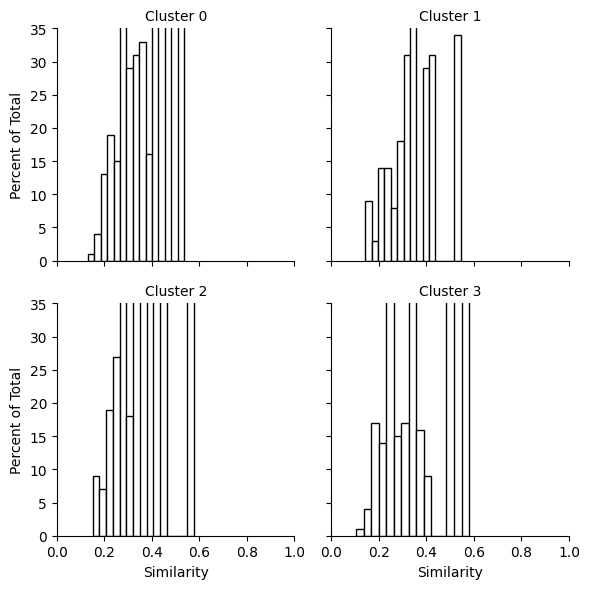

In [10]:
kmeans4 = KMeans(n_clusters=4, n_init=10, random_state=1234)
kmeans4.fit(df)

cluster_labels_4 = kmeans4.labels_
similarity = np.exp(-np.linalg.norm(df - kmeans4.cluster_centers_[cluster_labels_4], axis=1))

# Step 3: Make a DataFrame
import pandas as pd

df_similarity = pd.DataFrame({
    "Cluster": cluster_labels_4,
    "Similarity": similarity
})

g = sns.FacetGrid(df_similarity, col="Cluster", col_wrap=2, sharex=True, sharey=True)
g.map(plt.hist, "Similarity", bins=15, color="white", edgecolor="black")
g.set_axis_labels("Similarity", "Percent of Total")
g.set_titles("Cluster {col_name}")

for ax in g.axes.flatten():
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 35)

plt.tight_layout()
plt.show()


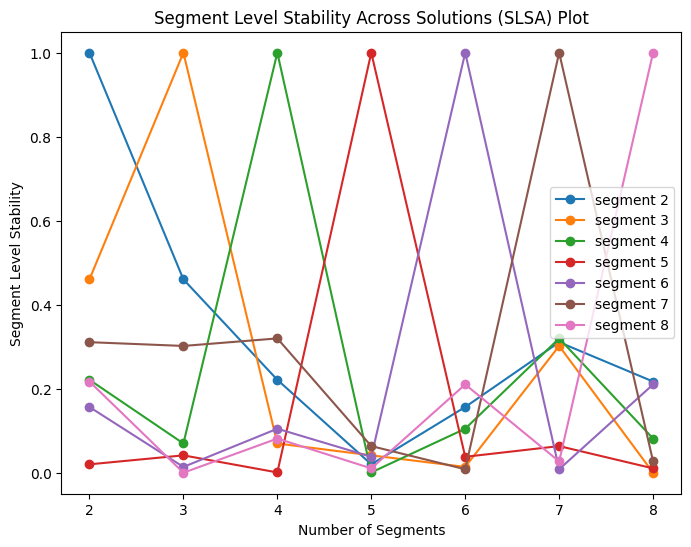

In [11]:
labels=[]

for i in range(2,9):
  labels.append(kmeans[i].predict(df))

plt.figure(figsize=(8,6))
for i, segment in enumerate(range(2,9)):
  plt.plot(range(2,9), [np.mean(labels[i]==k) for k in labels], marker='o', label=f"segment {segment}")

plt.xlabel('Number of Segments')
plt.ylabel('Segment Level Stability')
plt.title('Segment Level Stability Across Solutions (SLSA) Plot')
plt.xticks(range(2,9))
plt.legend()
plt.show()

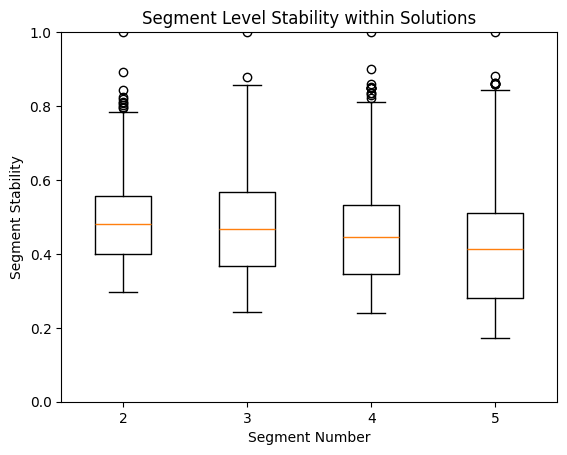

In [12]:
segment_labels = {}
segment_similarities = {}

for i in range(2,6):
    segment_labels[i] = kmeans[i].predict(df)
    segment_similarities[i] = kmeans[i].transform(df).min(axis=1)

segment_stability_values = []
for i in range(2,6):
    similarities = segment_similarities[i]
    normalized_similarities = similarities / np.max(similarities)
    segment_stability_values.append(normalized_similarities)

plt.boxplot(segment_stability_values, whis=1.5)
plt.xlabel("Segment Number")
plt.ylabel("Segment Stability")
plt.xticks(range(1, 5), range(2, 6))
plt.ylim(0, 1)
plt.title("Segment Level Stability within Solutions")
plt.show()

## 4. Using Mixture of Distribution

In [13]:
from scipy.special import logsumexp
np.random.seed(1234)
df = np.random.binomial(1, 0.5, size=(500, 10))

def initialize_parameters(n_clusters, n_features):
    weights = np.ones(n_clusters) / n_clusters
    probs = np.random.rand(n_clusters, n_features)
    return weights, probs

def e_step(X, weights, probs):
    n_samples, n_features = X.shape
    log_resp = np.zeros((n_samples, len(weights)))

    for k in range(len(weights)):
        # log(P(X|Z=k)) = sum over features of X*log(p) + (1-X)*log(1-p)
        log_prob = X @ np.log(probs[k] + 1e-10) + (1 - X) @ np.log(1 - probs[k] + 1e-10)
        log_resp[:, k] = np.log(weights[k] + 1e-10) + log_prob

    log_sum = logsumexp(log_resp, axis=1, keepdims=True)
    log_resp -= log_sum
    resp = np.exp(log_resp)
    log_likelihood = np.sum(log_sum)
    return resp, log_likelihood

def m_step(X, resp):
    nk = resp.sum(axis=0)
    weights = nk / nk.sum()
    probs = (resp.T @ X) / nk[:, np.newaxis]
    return weights, probs

def compute_icl(log_likelihood, resp):
    entropy = -np.sum(resp * np.log(resp + 1e-10))
    return -2 * log_likelihood + 2 * entropy

def fit_bernoulli_mixture(X, n_clusters, max_iter=100, tol=1e-4):
    n_samples, n_features = X.shape
    weights, probs = initialize_parameters(n_clusters, n_features)

    log_likelihood = None
    for iteration in range(max_iter):
        resp, new_log_likelihood = e_step(X, weights, probs)
        weights, probs = m_step(X, resp)

        if log_likelihood is not None and abs(new_log_likelihood - log_likelihood) < tol:
            break
        log_likelihood = new_log_likelihood

    n_params = n_clusters * n_features + (n_clusters - 1)
    aic = 2 * n_params - 2 * log_likelihood
    bic = np.log(n_samples) * n_params - 2 * log_likelihood
    icl = compute_icl(log_likelihood, resp)

    return {
        'k': n_clusters,
        'logLik': round(log_likelihood, 3),
        'AIC': round(aic, 2),
        'BIC': round(bic, 2),
        'ICL': round(icl, 2)
    }

# Run for k = 2 to 8
results = []
for k in range(2, 9):
    result = fit_bernoulli_mixture(df, n_clusters=k)
    results.append(result)

# Create results table
df_results = pd.DataFrame(results)
print(df_results)


   k    logLik      AIC      BIC      ICL
0  2 -3452.507  6947.01  7035.52  7398.14
1  3 -3445.699  6955.40  7090.27  7581.83
2  4 -3435.290  6956.58  7137.81  7381.13
3  5 -3431.346  6970.69  7198.28  7719.32
4  6 -3417.868  6965.74  7239.69  7352.11
5  7 -3413.419  6978.84  7299.15  7499.21
6  8 -3410.117  6994.23  7360.91  7494.95


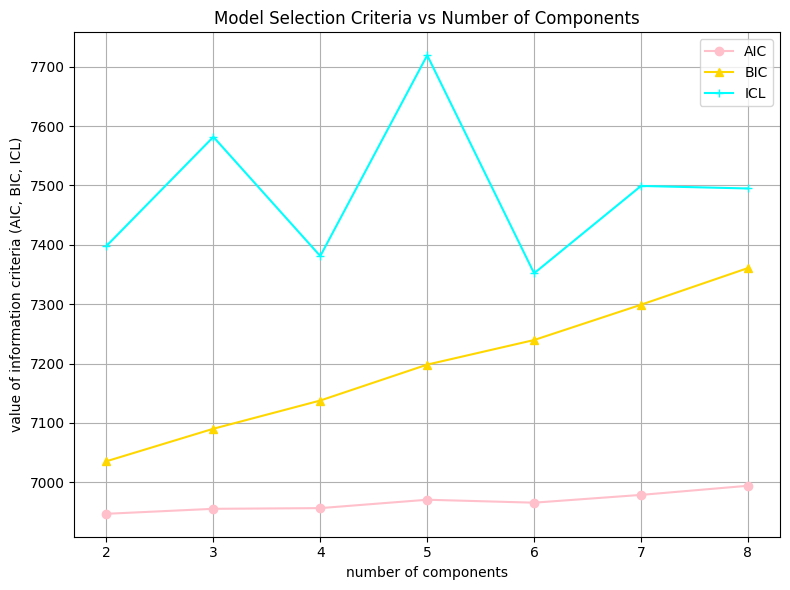

In [14]:
# Plotting
plt.figure(figsize=(8, 6))
plt.plot(df_results['k'], df_results['AIC'], marker='o', color='pink', label='AIC')
plt.plot(df_results['k'], df_results['BIC'], marker='^', color='gold', label='BIC')
plt.plot(df_results['k'], df_results['ICL'], marker='+', color='cyan', label='ICL')

plt.xlabel("number of components")
plt.ylabel("value of information criteria (AIC, BIC, ICL)")
plt.title("Model Selection Criteria vs Number of Components")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
# Assuming MD_x is your dataset (binary or numeric)
# Step 1: KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=1234)
kmeans_labels = kmeans.fit_predict(df)

# Step 2: Mixture model clustering (e.g., GaussianMixture)
gmm = GaussianMixture(n_components=4, random_state=1234)
gmm_labels = gmm.fit_predict(df)

# Step 3: Cross-tabulation like R's table()
conf_matrix = pd.crosstab(index=pd.Series(kmeans_labels, name='kmeans'),
                          columns=pd.Series(gmm_labels, name='mixture'))

print(conf_matrix)


mixture    0   1    2   3
kmeans                   
0        123   0    0   0
1          0  19   68  33
2          0   0  128   0
3          0   0   31  98


In [16]:
# Step 1: KMeans clustering (provides initial cluster assignments)
kmeans = KMeans(n_clusters=4, random_state=1234)
kmeans_labels = kmeans.fit_predict(df)

# Step 2: Use KMeans labels as initialization for GaussianMixture
gmm = GaussianMixture(n_components=4, random_state=1234,
                      init_params='kmeans', max_iter=100)

# Manually assign initial means based on KMeans (optional, more precise)
gmm.fit(df)  # initial fit
gmm.means_init = np.array([df[kmeans_labels == i].mean(axis=0) for i in range(4)])

# Final model fit
gmm_labels = gmm.fit_predict(df)

# Step 3: Cross-tabulation (similar to R's table())
conf_matrix = pd.crosstab(index=pd.Series(kmeans_labels, name="kmeans"),
                          columns=pd.Series(gmm_labels, name="mixture"))

print(conf_matrix)

mixture    0   1    2   3
kmeans                   
0        123   0    0   0
1          0  19   68  33
2          0   0  128   0
3          0   0   31  98


In [17]:
print("Log-likelihood (GMM):", gmm.score(df) * len(df))
ll1 = gmm.score(df) * len(df)
ll2 = gmm.score(df) * len(df)
print("LogLik GMM1:", ll1)



Log-likelihood (GMM): 1433.9937185429285
LogLik GMM1: 1433.9937185429285


## 5. Using Mixtures of Regression Model

In [18]:
# Converting Ordinal variable to Numerical variable
like_counts = mcdonalds["Like"].value_counts(ascending=True)
print(like_counts)

Like
-1               58
-2               59
-4               71
-3               73
I love it!+5    143
+1              152
I hate it!-5    152
+4              160
0               169
+2              187
+3              229
Name: count, dtype: int64


In [19]:
# Convert 'Like' to numeric codes, subtract from 6 to reverse the scale
mcdonalds["Like_n"] = 6 - mcdonalds["Like"].astype('category').cat.codes

# Display frequency count
like_n_counts = mcdonalds["Like_n"].value_counts().sort_index()
print(like_n_counts)

Like_n
-4    143
-3    152
-2    169
-1     71
 0     73
 1     59
 2     58
 3    160
 4    229
 5    187
 6    152
Name: count, dtype: int64


In [20]:
# Step 1: Prepare data
X = mcdonalds.iloc[:, :11].replace({"Yes": 1, "No": 0})  # independent variables
y = mcdonalds["Like_n"]     # dependent variable

# Step 2: Scale features (optional but helps with GaussianMixture)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Fit Gaussian Mixture Model to cluster the data
gmm = GaussianMixture(n_components=2, n_init=10, random_state=1234)
clusters = gmm.fit_predict(X_scaled)

# Step 4: Fit logistic regression for each cluster
mcdonalds["cluster"] = clusters
models = {}

for c in np.unique(clusters):
    X_c = sm.add_constant(X[mcdonalds["cluster"] == c])
    y_c = y[mcdonalds["cluster"] == c]
    model = sm.OLS(y_c, X_c).fit()
    models[c] = model
    print(f"\nModel for cluster {c}")
    print(model.summary())

C:\Users\KIIT\AppData\Local\Temp\ipykernel_22732\504092390.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = mcdonalds.iloc[:, :11].replace({"Yes": 1, "No": 0})  # independent variables



Model for cluster 0
                            OLS Regression Results                            
Dep. Variable:                 Like_n   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     9.165
Date:                Sun, 04 May 2025   Prob (F-statistic):           1.34e-14
Time:                        00:03:28   Log-Likelihood:                -927.96
No. Observations:                 393   AIC:                             1880.
Df Residuals:                     381   BIC:                             1928.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1759      0.62

C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


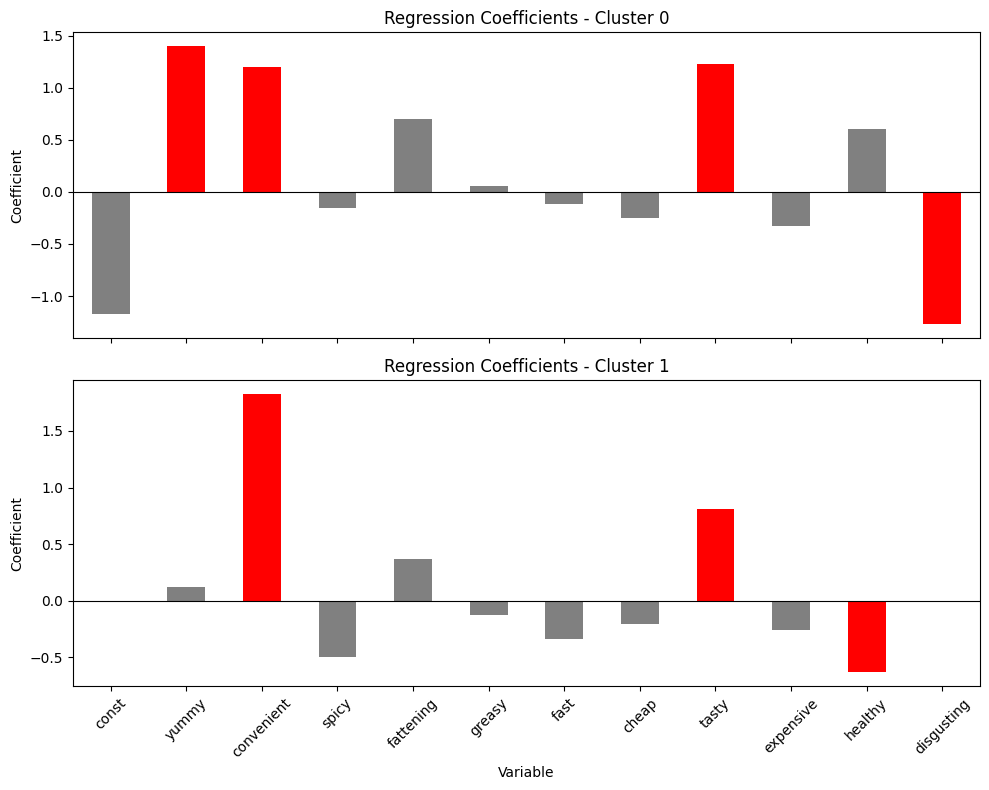

In [21]:
# Store coefficients and significance info
coefs = []
pvals = []
cluster_labels = []

for cluster_id in np.unique(clusters):
    X_cluster = X[clusters == cluster_id]
    y_cluster = y[clusters == cluster_id]
    X_cluster_const = sm.add_constant(X_cluster)

    model = sm.OLS(y_cluster, X_cluster_const).fit()
    coefs.append(model.params)
    pvals.append(model.pvalues)
    cluster_labels.append(f"Cluster {cluster_id}")

# Convert to DataFrame
import pandas as pd
coef_df = pd.DataFrame(coefs, index=cluster_labels)
pval_df = pd.DataFrame(pvals, index=cluster_labels)

# Plot
fig, axes = plt.subplots(nrows=len(coefs), figsize=(10, 4 * len(coefs)), sharex=True)

if len(coefs) == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    coef_df.iloc[i].plot(kind='bar', ax=ax, color=[
        'red' if pval < 0.05 else 'gray' for pval in pval_df.iloc[i]
    ])
    ax.set_title(f"Regression Coefficients - {coef_df.index[i]}")
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel("Coefficient")
    ax.set_xlabel("Variable")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Profiling Segments

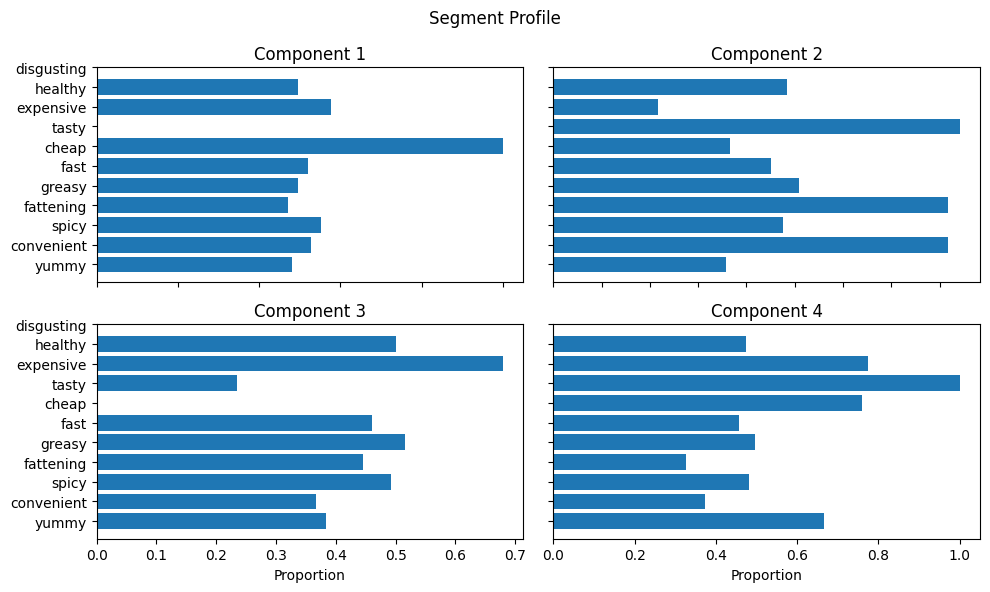

In [28]:
custom_labels = [
    'yummy', 'convenient', 'spicy', 'fattening', 'greasy',
    'fast', 'cheap', 'tasty', 'expensive', 'healthy', 'disgusting'
]
df=pd.DataFrame(df)
km = KMeans(n_clusters=4, random_state=1234)
labels = km.fit_predict(df)
df_mean = df.groupby(labels).mean()

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

for i in range(1, 5):
    row = (i - 1) // 2
    col = (i - 1) % 2
    axs[row, col].barh(range(df_mean.shape[1]), df_mean.iloc[i - 1])
    axs[row, col].set_title(f'Component {i}')
    axs[row, col].set_yticks(range(len(custom_labels)))
    axs[row, col].set_yticklabels(custom_labels)

for ax in axs.flat:
     ax.set(xlabel='Proportion')
     ax.label_outer()

fig.suptitle("Segment Profile")
fig.tight_layout()
plt.show()

## 7. Describing Segment